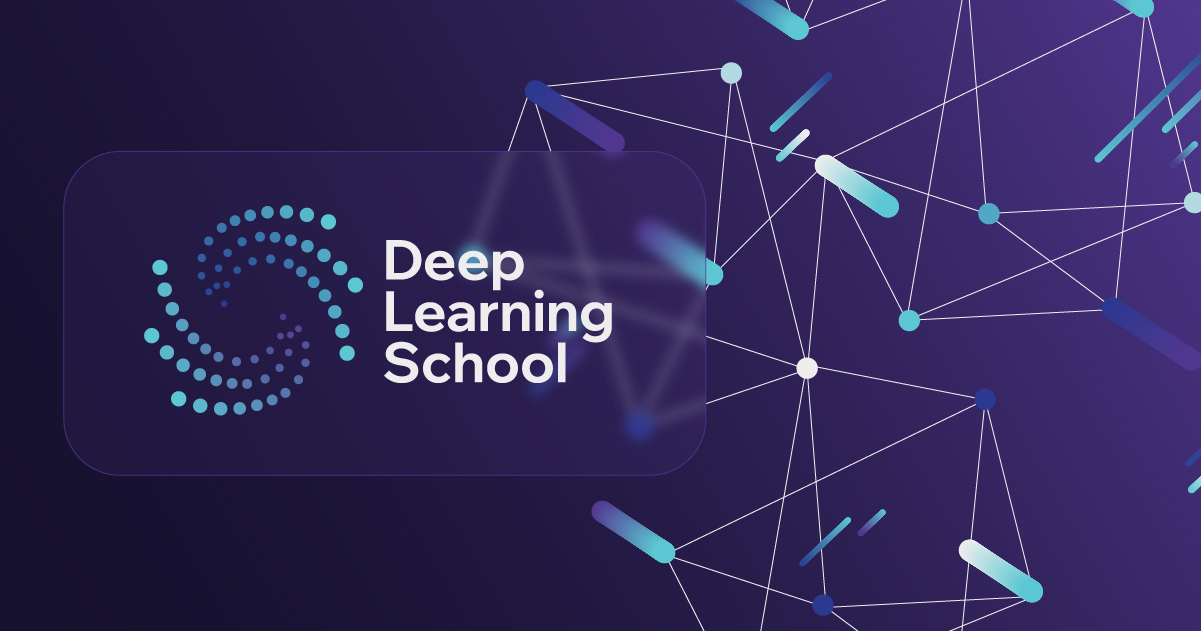

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Эмбеддинги.</b></h1>


***Some parts of the notebook are almost the copy of [ mmta-team course](https://github.com/mmta-team/mmta_fall_2020). Special thanks to mmta-team for making them publicly available. [Original notebook](https://github.com/mmta-team/mmta_fall_2020/blob/master/tasks/01_word_embeddings/task_word_embeddings.ipynb).***

<b> Прочитайте семинар, пожалуйста, для успешного выполнения домашнего задания. В конце ноутбука напишите свой вывод. Работа без вывода оценивается ниже.

## Задача поиска схожих по смыслу предложений

Мы будем ранжировать вопросы [StackOverflow](https://stackoverflow.com) на основе семантического векторного представления.

До этого в курсе не было речи про задачу ранжирования, поэтому введем её математическую формулировку.

## Задача ранжирования(Learning to Rank)

* $X$ - множество объектов
* $X^l = \{x_1, x_2, ..., x_l\}$ - обучающая выборка
<br>На обучающей выборке задан порядок между некоторыми элементами, то есть нам известно, что некий объект выборки более релевантный для нас, чем другой:
* $i \prec j$ - порядок пары индексов объектов на выборке $X^l$ c индексами $i$ и $j$
### Задача:
построить ранжирующую функцию $a$ : $X \rightarrow R$ такую, что
$$i \prec j \Rightarrow a(x_i) < a(x_j)$$

### Embeddings

Будем использовать предобученные векторные представления слов на постах Stack Overflow.<br>
[A word2vec model trained on Stack Overflow posts](https://github.com/vefstathiou/SO_word2vec)

In [12]:
!wget https://zenodo.org/record/1199620/files/SO_vectors_200.bin?download=1

--2026-09-24 14:43:03--  https://zenodo.org/record/1199620/files/SO_vectors_200.bin?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 137.138.153.219, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1199620/files/SO_vectors_200.bin [following]
--2026-09-24 14:43:04--  https://zenodo.org/records/1199620/files/SO_vectors_200.bin
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1453905423 (1.4G) [application/octet-stream]
Saving to: ‘SO_vectors_200.bin?download=1’

SO_vectors_200.bin? 100%[===================>]   1.35G  2.01MB/s    in 17m 13s 

2026-09-24 15:00:17 (1.34 MB/s) - ‘SO_vectors_200.bin?download=1’ saved [1453905423/1453905423]



In [13]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 10.9 MB/s eta 0:00:00


In [14]:
from gensim.models.keyedvectors import KeyedVectors
wv_embeddings = KeyedVectors.load_word2vec_format("SO_vectors_200.bin?download=1", binary=True)

#### Как пользоваться этими векторами?

Рассмотрим на примере одного слова, что из себя представляет embedding.

In [ ]:
word = 'dog'
if word in wv_embeddings:
    print(wv_embeddings[word].dtype, wv_embeddings[word].shape)

float32 (200,)


In [ ]:
print(f"Num of words: {len(wv_embeddings.index_to_key)}")

Num of words: 1787145


Найдем наиболее близкие слова к слову `dog`:

#### ***Вопрос 1***:
* Входит ли слово `cat` в топ-5 близких слов к слову `dog`?
* Какое место занимает слово `cat` в наиболее близких словах к слову `dog`?

In [ ]:
import torch
import numpy as np

In [ ]:
# method most_simmilar
def cosine_similarity(emb_a, emb_b):
    return emb_a @ emb_b / (np.linalg.norm(emb_a, ord=2) * np.linalg.norm(emb_b, ord=2))

def get_similarity_mtrx(embeddings, word):
    embs = embeddings.vectors / np.linalg.norm(embeddings.vectors, ord=2, axis=1).reshape(-1, 1)
    target_vector = embs[embeddings.key_to_index[word]]
    similarity_mtrx = embs @ target_vector
    return similarity_mtrx

def most_similar_handmade(embeddings, word, topn=5):
    mtrx = get_similarity_mtrx(embeddings, word)
    sorted_indices = np.argsort(mtrx)[::-1]

    res = []
    for idx in sorted_indices:
        if idx == embeddings.key_to_index[word]: continue
        word_key = embeddings.index_to_key[idx]
        res.append((word_key, mtrx[idx]))
        if len(res) == topn:
            break

    return res

In [ ]:
cosine_similarity(wv_embeddings['cat'], wv_embeddings['dog'])

np.float32(0.6852342)

In [ ]:
most_similar_handmade(wv_embeddings, 'cat')

[('-vet', np.float32(0.7583355)),
 ('dog', np.float32(0.6852341)),
 ('/proc/version', np.float32(0.6815889)),
 ('feline', np.float32(0.67799664)),
 ('nyan', np.float32(0.66851974))]

In [ ]:
# слишком долго
# all_similarities = []
# words = list(wv_embeddings.key_to_index.keys())
# for word in words:
#     all_similarities.append(cosine_similarity(wv_embeddings['cat'], wv_embeddings[f'{word}']))

In [ ]:
best_similarity = wv_embeddings.most_similar('cat', topn=5)
best_similarity

[('-vet', 0.7583354711532593),
 ('dog', 0.6852341890335083),
 ('/proc/version', 0.6815888285636902),
 ('feline', 0.6779966950416565),
 ('nyan', 0.6685197353363037)]

***Ваш ответ:***
Dog входит в топ-5 самых близких слов к слову cat, занимает 2 место. Написанная мной функция выдает такой же результат, как и библиотечная

### Векторные представления текста

Перейдем от векторных представлений отдельных слов к векторным представлениям вопросов, как к **среднему** векторов всех слов в вопросе. Если для какого-то слова нет предобученного вектора, то его нужно пропустить. Если вопрос не содержит ни одного известного слова, то нужно вернуть нулевой вектор.

In [16]:
import numpy as np
import re
# you can use your tokenizer
# for example, from nltk.tokenize import WordPunctTokenizer
class MyTokenizer:
    def __init__(self):
        pass
    def tokenize(self, text):
        return re.findall('\w+', text)
tokenizer = MyTokenizer()

<>:9: SyntaxWarning: invalid escape sequence '\w'
<>:9: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_1951/2760772041.py:9: SyntaxWarning: invalid escape sequence '\w'
  return re.findall('\w+', text)


In [17]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [18]:
tokenizer = word_tokenize

In [77]:
def question_to_vec(question, embeddings, tokenizer, dim=200):
    """
        question: строка
        embeddings: наше векторное представление
        dim: размер любого вектора в нашем представлении

        return: векторное представление для вопроса
    """

    tokens = tokenizer(question)
    res = np.zeros(dim)
    cnt = 0
    for token in tokens:
        if token in embeddings:
            v = embeddings[token]
            norm = np.linalg.norm(v)
            if norm > 0:
                res += v / norm
                cnt += 1
    return res / cnt if cnt != 0 else res

In [55]:
question_to_vec("Sergey is a cool person", wv_embeddings, tokenizer).shape

(200,)

Теперь у нас есть метод для создания векторного представления любого предложения.

#### ***Вопрос 2***:
* Какая третья(с индексом 2) компонента вектора предложения `I love neural networks` (округлите до 2 знаков после запятой)?

In [56]:
question_to_vec("I love neural networks", wv_embeddings, tokenizer)[2].round(2)

np.float64(-0.05)

***Ваш ответ:***
-0.05

### Оценка близости текстов

Представим, что мы используем идеальные векторные представления слов. Тогда косинусное расстояние между дублирующими предложениями должно быть меньше, чем между случайно взятыми предложениями.

Сгенерируем для каждого из $N$ вопросов $R$ случайных отрицательных примеров и примешаем к ним также настоящие дубликаты. Для каждого вопроса будем ранжировать с помощью нашей модели $R + 1$ примеров и смотреть на позицию дубликата. Мы хотим, чтобы дубликат был первым в ранжированном списке.

#### Hits@K
Первой простой метрикой будет количество корректных попаданий для какого-то $K$:
$$ \text{Hits@K} = \frac{1}{N}\sum_{i=1}^N \, [rank\_q_i^{'} \le K],$$
* $\begin{equation*}
[x < 0 ] \equiv
 \begin{cases}
   1, &x < 0\\
   0, &x \geq 0
 \end{cases}
\end{equation*}$ - индикаторная функция
* $q_i$ - $i$-ый вопрос
* $q_i^{'}$ - его дубликат
* $rank\_q_i^{'}$ - позиция дубликата в ранжированном списке ближайших предложений для вопроса $q_i$.

Hits@K  измеряет долю вопросов, для которых правильный ответ попал в топ-K позиций среди отранжированных кандидатов.

#### DCG@K
Второй метрикой будет упрощенная DCG метрика, учитывающая порядок элементов в списке путем домножения релевантности элемента на вес равный обратному логарифму номера позиции:
$$ \text{DCG@K} = \frac{1}{N} \sum_{i=1}^N\frac{1}{\log_2(1+rank\_q_i^{'})}\cdot[rank\_q_i^{'} \le K],$$
С такой метрикой модель штрафуется за большой ранк корректного ответа.

DCG@K  измеряет качество ранжирования, учитывая не только факт наличия правильного ответа в топ-K, но и ***его точную позицию***.

<img src='https://hsto.org/files/1c5/edf/dee/1c5edfdeebce4b71a86bdf986d9f88f2.jpg' width=400, height=200>

#### Пример оценок

Вычислим описанные выше метрики для игрушечного примера.
Пусть
* $N = 1$, $R = 3$
* <font color='green'>"Что такое python?"</font> - вопрос $q_1$
* <font color='red'>"Что такое язык python?"</font> - его дубликат $q_i^{'}$

Пусть модель выдала следующий ранжированный список кандидатов:

1. "Как изучить с++?"
2. <font color='red'>"Что такое язык python?"</font>
3. "Хочу учить Java"
4. "Не понимаю Tensorflow"

$\Rightarrow rank\_q_i^{'} = 2$

Вычислим метрику *DCG@K* для *K = 1, 4*:
- [K = 1] $\text{DCG@1} = \frac{1}{\log_2(1+2)}\cdot[2 \le 1] = 0$
- [K = 4] $\text{DCG@4} = \frac{1}{\log_2(1+2)}\cdot[2 \le 4] = \frac{1}{\log_2{3}}$

Вычислим метрику *Hits@K* для *K = 1, 4*:

- [K = 1] $\text{Hits@1} =  [rank\_q_i^{'} \le 1]$

Проверяем условие $ \text{rank}_{q'_1} \leq 1 $: ***условие неверно***.

Следовательно, $[\text{rank}_{q'_1} \leq 1] = 0$.

[K = 1] $\text{Hits@1} = 0$

- [K = 4] $\text{Hits@4} =  [rank\_q_i^{'} \le 4]$

Проверяем условие $ \text{rank}_{q'_1} \leq 4 $: ***условие верно***.

[K = 4] $\text{Hits@4} = 1$

Вычислим метрику *DCG@K* для *K = 1, 4*:
- [K = 1] $\text{DCG@1} = \frac{1}{\log_2(1+2)}\cdot[2 \le 1] = 0$
- [K = 4] $\text{DCG@4} = \frac{1}{\log_2(1+2)}\cdot[2 \le 4] = \frac{1}{\log_2{3}}$

#### ***Вопрос 3***:
* Вычислите `DCG@10`, если $rank\_q_i^{'} = 9$ (округлите до одного знака после запятой).

***Ваш ответ:***
0.3010299956639812

***Ваше решение:***
$\text{DCG@10} = \frac{1}{\log_2(1+9)}\cdot[9 \le 10] = \frac{1}{\log_2{10}}$

In [ ]:
rank_q = 9
dcg10 = 1 / np.log2(1 + 9) * (rank_q <= 10)
dcg10

np.float64(0.3010299956639812)

#### Более сложный пример оценок

Рассмотрим пример с $ N > 1 $, где $ N = 3 $ (три вопроса) и для каждого вопроса заданы позиции их дубликатов. Вычислим метрики **Hits@K** для разных значений $ K $.

---

- $ N = 3 $: Три вопроса ($ q_1, q_2, q_3 $).
- Для каждого вопроса известна позиция его дубликата ($ \text{rank}_{q'_i} $):
  - $ \text{rank}_{q'_1} = 2 $,
  - $ \text{rank}_{q'_2} = 5 $,
  - $ \text{rank}_{q'_3} = 1 $.

Мы будем вычислять **Hits@K** для $ K = 1, 5 $.

---

**Для $ K = 1 $:**

Подставим значения:
$$
\text{Hits@1} = \frac{1}{3} \cdot \left( [\text{rank}_{q'_1} \leq 1] + [\text{rank}_{q'_2} \leq 1] + [\text{rank}_{q'_3} \leq 1] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 1 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 1 $ → $ 1 $.

Сумма:
$$
\text{Hits@1} = \frac{1}{3} \cdot (0 + 0 + 1) = \frac{1}{3}.
$$

$$
\boxed{\text{Hits@1} = \frac{1}{3}}.
$$

---

**Для $ K = 5 $:**

Подставим значения:
$$
\text{Hits@5} = \frac{1}{3} \cdot \left( [\text{rank}_{q'_1} \leq 5] + [\text{rank}_{q'_2} \leq 5] + [\text{rank}_{q'_3} \leq 5] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 5 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 5 $ → $ 1 $.

Сумма:
$$
\text{Hits@5} = \frac{1}{3} \cdot (1 + 1 + 1) = 1.
$$

$$
\boxed{\text{Hits@5} = 1}.
$$

Теперь вычислим метрику **DCG@K** для того же примера, где $ N = 3 $ (три вопроса), и для каждого вопроса известна позиция его дубликата ($ \text{rank}_{q'_i} $):

- $ \text{rank}_{q'_1} = 2 $,
- $ \text{rank}_{q'_2} = 5 $,
- $ \text{rank}_{q'_3} = 1 $.

Мы будем вычислять **DCG@K** для $ K = 1, 5 $.

---
**Для $ K = 1 $:**
Подставим значения:
$$
\text{DCG@1} = \frac{1}{3} \cdot \left( \frac{1}{\log_2(1 + \text{rank}_{q'_1})} \cdot [\text{rank}_{q'_1} \leq 1] + \frac{1}{\log_2(1 + \text{rank}_{q'_2})} \cdot [\text{rank}_{q'_2} \leq 1] + \frac{1}{\log_2(1 + \text{rank}_{q'_3})} \cdot [\text{rank}_{q'_3} \leq 1] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 1 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 1 $ → $ 1 $.

Сумма:
$$
\text{DCG@1} = \frac{1}{3} \cdot (0 + 0 + 1) = \frac{1}{3}.
$$
$$
\boxed{\text{DCG@1} = \frac{1}{3}}.
$$

---


**Для $ K = 5 $:**
Подставим значения:
$$
\text{DCG@5} = \frac{1}{3} \cdot \left( \frac{1}{\log_2(1 + \text{rank}_{q'_1})} \cdot [\text{rank}_{q'_1} \leq 5] + \frac{1}{\log_2(1 + \text{rank}_{q'_2})} \cdot [\text{rank}_{q'_2} \leq 5] + \frac{1}{\log_2(1 + \text{rank}_{q'_3})} \cdot [\text{rank}_{q'_3} \leq 5] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 5 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 5 $ → $ 1 $.

Сумма:
$$
\text{DCG@5} = \frac{1}{3} \cdot (0.631 + 0.387 + 1) = \frac{1}{3} \cdot 2.018 \approx 0.673.
$$

$$
\boxed{\text{DCG@5} \approx 0.673}.
$$

#### ***Вопрос 4:***
* Какое максимальное значение может принимать `Hits@47 - DCG@1`?

***Ваш ответ:***
Максимальное значение будет равно 1

***Ваше решение:***
Максимальное значение можно получить, если hits = 1, а dcg = 0 (1 -максимальное для обоих метрик, 0 - минимальное).Так получится, если rank_q будет от 2 до 47 включительно. тогда hits будет = 1, а dcg будет = 0, тк rank_q > 1

### HITS\_COUNT и DCG\_SCORE

Каждая функция имеет два аргумента: $dup\_ranks$ и $k$.

$dup\_ranks$ является списком, который содержит рейтинги дубликатов (их позиции в ранжированном списке).

К примеру для <font color='red'>"Что такое язык python?"</font> $dup\_ranks = [2]$.

In [57]:
def hits_count(dup_ranks, k):
    """
        dup_ranks: list индексов дубликатов
        k: пороговое значение для ранга
        result: вернуть Hits@k
    """
    hits_value = np.array(dup_ranks) <= k
    return hits_value.astype(int).mean()

In [ ]:
# Расчитаем метрику Hits с помощью реализованных функций
dup_ranks = [2]

hits_value = hits_count(dup_ranks, k=1)
print(f"Hits@1 = {hits_value}")

hits_value = hits_count(dup_ranks, k=4)
print(f"Hits@4 = {hits_value}")

Hits@1 = 0.0
Hits@4 = 1.0


In [58]:
def dcg_score(dup_ranks, k):
    """
        dup_ranks: list индексов дубликатов
        k: пороговое значение для ранга
        result: вернуть DCG@k
    """
    dup_ranks = np.array(dup_ranks)
    dcg_value = 1 / np.log2(1 + dup_ranks) * (dup_ranks <= k)
    return dcg_value.mean()

In [ ]:
# Расчитаем метрику DCG с помощью реализованных функций
dup_ranks = [2]

# Вычисляем DCG@1
dcg_value = dcg_score(dup_ranks, k=1)
print(f"DCG@1 = {dcg_value:.3f}")

# Вычисляем DCG@4
dcg_value = dcg_score(dup_ranks, k=4)
print(f"DCG@4 = {dcg_value:.3f}")

DCG@1 = 0.000
DCG@4 = 0.631


Протестируем функции. Пусть $N = 1$, то есть у нас один эксперимент. Будем искать копию вопроса и оценивать метрики.

In [ ]:
import pandas as pd

In [ ]:
copy_answers = ["How does the catch keyword determine the type of exception that was thrown",]

# наши кандидаты
candidates_ranking = [["How Can I Make These Links Rotate in PHP",
                       "How does the catch keyword determine the type of exception that was thrown",
                       "NSLog array description not memory address",
                       "PECL_HTTP not recognised php ubuntu"],]

# dup_ranks — позиции наших копий, так как эксперимент один, то этот массив длины 1
dup_ranks = [2]

# вычисляем метрику для разных k
print('Ваш ответ HIT:', [hits_count(dup_ranks, k) for k in range(1, 5)])
print('Ваш ответ DCG:', [round(dcg_score(dup_ranks, k), 5) for k in range(1, 5)])

Ваш ответ HIT: [np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Ваш ответ DCG: [np.float64(0.0), np.float64(0.63093), np.float64(0.63093), np.float64(0.63093)]


У вас должно получиться:

In [ ]:
# correct_answers - метрика для разных k
correct_answers = pd.DataFrame([[0, 1, 1, 1], [0, 1 / (np.log2(3)), 1 / (np.log2(3)), 1 / (np.log2(3))]],
                               index=['HITS', 'DCG'], columns=range(1,5))
correct_answers

,1,2,3,4
HITS,0,1.00000,1.00000,1.00000
DCG,0,0.63093,0.63093,0.63093


### Данные
[arxiv link](https://drive.google.com/file/d/1QqT4D0EoqJTy7v9VrNCYD-m964XZFR7_/edit)

`train.tsv` - выборка для обучения.<br> В каждой строке через табуляцию записаны: **<вопрос>, <похожий вопрос>**

`validation.tsv` - тестовая выборка.<br> В каждой строке через табуляцию записаны: **<вопрос>, <похожий вопрос>, <отрицательный пример 1>, <отрицательный пример 2>, ...**

In [2]:
!gdown "https://drive.google.com/uc?id=1QqT4D0EoqJTy7v9VrNCYD-m964XZFR7_" -O stackoverflow_similar_questions.zip

Downloading...
From (original): https://drive.google.com/uc?id=1QqT4D0EoqJTy7v9VrNCYD-m964XZFR7_
From (redirected): https://drive.google.com/uc?id=1QqT4D0EoqJTy7v9VrNCYD-m964XZFR7_&confirm=t&uuid=d8e42bd7-39a3-4998-bb8a-28b12a790006
To: /content/stackoverflow_similar_questions.zip
100% 131M/131M [00:01<00:00, 104MB/s]


In [3]:
!unzip stackoverflow_similar_questions.zip

Archive:  stackoverflow_similar_questions.zip
   creating: data/
  inflating: data/.DS_Store          
   creating: __MACOSX/
   creating: __MACOSX/data/
  inflating: __MACOSX/data/._.DS_Store  
  inflating: data/train.tsv          
  inflating: data/validation.tsv     


Считайте данные.

In [4]:
def read_corpus(filename):
    data = []
    with open(filename, encoding='utf-8') as file:
        for line in file:
            data.append(line.strip().split('\t'))
    return data

Нам понадобиться только файл validation.

In [5]:
validation_data = read_corpus('./data/validation.tsv')

Кол-во строк

In [6]:
len(validation_data)

3760

Размер нескольких первых строк

In [7]:
for i in range(5):
    print(i + 1, len(validation_data[i]))

1 1001
2 1001
3 1001
4 1001
5 1001


### Ранжирование без обучения

Реализуйте функцию ранжирования кандидатов на основе косинусного расстояния. Функция должна по списку кандидатов вернуть отсортированный список пар (позиция в исходном списке кандидатов, кандидат). При этом позиция кандидата в полученном списке является его рейтингом (первый - лучший). Например, если исходный список кандидатов был [a, b, c], и самый похожий на исходный вопрос среди них - c, затем a, и в конце b, то функция должна вернуть список **[(2, c), (0, a), (1, b)]**.

In [8]:
from sklearn.metrics.pairwise import cosine_similarity
from copy import deepcopy

In [76]:
def rank_candidates(question, candidates, embeddings, tokenizer, dim=200):
    """
        question: строка
        candidates: массив строк(кандидатов) [a, b, c]
        result: пары (начальная позиция, кандидат) [(2, c), (0, a), (1, b)]
    """
    question_embed = question_to_vec(question, embeddings, tokenizer, dim).reshape(1, -1)

    candidates_embed = np.array([question_to_vec(cand, embeddings, tokenizer, dim) for cand in candidates])

    cosine_scores = cosine_similarity(question_embed, candidates_embed)[0]
    idxs = np.argsort(cosine_scores)[::-1]

    result = [(idx.item(), candidates[idx]) for idx in idxs]
    return result

Протестируйте работу функции на примерах ниже. Пусть $N=2$, то есть два эксперимента

In [60]:
questions = ['converting string to list', 'Sending array via Ajax fails']

candidates = [['Convert Google results object (pure js) to Python object', # первый эксперимент
               'C# create cookie from string and send it',
               'How to use jQuery AJAX for an outside domain?'],

              ['Getting all list items of an unordered list in PHP',      # второй эксперимент
               'WPF- How to update the changes in list item of a list',
               'select2 not displaying search results']]

In [61]:
for question, q_candidates in zip(questions, candidates):
        ranks = rank_candidates(question, q_candidates, wv_embeddings, tokenizer)
        print(ranks)
        print()

[(1, 'C# create cookie from string and send it'), (0, 'Convert Google results object (pure js) to Python object'), (2, 'How to use jQuery AJAX for an outside domain?')]

[(1, 'WPF- How to update the changes in list item of a list'), (0, 'Getting all list items of an unordered list in PHP'), (2, 'select2 not displaying search results')]



Для первого экперимента вы можете полностью сравнить ваши ответы и правильные ответы. Но для второго эксперимента два ответа на кандидаты будут <b>скрыты</b>(*)

In [62]:
# должно вывести
results = [[(1, 'C# create cookie from string and send it'),
            (0, 'Convert Google results object (pure js) to Python object'),
            (2, 'How to use jQuery AJAX for an outside domain?')],
           [(1, 'Getting all list items of an unordered list in PHP'), #скрыт
            (0, 'select2 not displaying search results'), #скрыт
            (2, 'WPF- How to update the changes in list item of a list')]] #скрыт

Вы должны получить `для эксперимента 1` следующую последовательность: `1, 0, 2`.

#### ***Вопрос 5:***
* Какую последовательность начальных индексов вы получили `для эксперимента 2`? (перечислите без запятой и пробелов, например, `102` для первого эксперимента)

***Ваш ответ:***
102

Теперь мы можем оценить качество нашего метода. Запустите следующие два блока кода для получения результата. Обратите внимание, что вычисление расстояния между векторами занимает некоторое время (примерно 10 минут). Можете взять для validation 1000 примеров.

In [24]:
from tqdm.notebook import tqdm

In [ ]:
wv_ranking = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates(q, ex, wv_embeddings, tokenizer)
    wv_ranking.append([r[0] for r in ranks].index(0) + 1)

  0%|          | 0/3760 [00:00<?, ?it/s]

In [ ]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.267 | Hits@   1: 0.267
DCG@   5: 0.319 | Hits@   5: 0.366
DCG@  10: 0.339 | Hits@  10: 0.428
DCG@ 100: 0.388 | Hits@ 100: 0.672
DCG@ 500: 0.414 | Hits@ 500: 0.874
DCG@1000: 0.427 | Hits@1000: 1.000


Из формул выше можно понять, что

- $ \text{Hits@K} $ **монотонно неубывающая функция** $ K $, которая стремится к 1 при $ K \to \infty $.

- $ \text{DCG@K} $ **монотонно неубывающая функция** $ K $, но рост замедляется с увеличением $ K $ из-за убывания веса $ \frac{1}{\log_2(1 + \text{rank}_{q'_i})} $.

### Эмбеддинги, обученные на корпусе похожих вопросов

In [25]:
train_data = read_corpus('./data/train.tsv')

Улучшите качество модели.<br>Склеим вопросы в пары и обучим на них модель Word2Vec из gensim. Выберите размер window. Объясните свой выбор.

***Рассмотрим подробнее*** данное склеивание.

1. Каждая строка из train_data разбивается на вопрос (question) и список кандидатов.

2. Для каждого кандидата вопрос склеивается с ним в одну строку.

3. Склеенная строка (combined_text) токенизируется, и полученный список токенов добавляется в общий корпус (corpus).

***Пример***

    Вопрос: "What is Python?"
    Кандидаты: ["Python is a programming language", "Java is another language"]
    Склеенные строки:
        "What is Python? Python is a programming language"
        "What is Python? Java is another language"
         
    Токенизированные списки:
        ['what', 'is', 'python', 'python', 'is', 'a', 'programming', 'language']
        ['what', 'is', 'python', 'java', 'is', 'another', 'language']

In [26]:
import string

def cat_train_data(train_data, tokenizer):
    res_tokens = []
    question_lens = []
    candidate_lens = []
    for raw in tqdm(train_data):
        question = raw[0]
        question_tokens = [w.lower() for w in tokenizer(question) if w not in string.punctuation]
        question_lens.append(len(question_tokens))

        for cand in raw[1:]:
            cand_tokens = [w.lower() for w in tokenizer(cand) if w not in string.punctuation]
            res_tokens.append(question_tokens + cand_tokens)
            candidate_lens.append(len(cand_tokens))

    return res_tokens, question_lens, candidate_lens

In [27]:
a = ["What is Python?", "Python is a programming language", "Java is another language"]
res_tokens, question_lens, candidate_lens = cat_train_data([a], tokenizer)

  0%|          | 0/1 [00:00<?, ?it/s]

In [28]:
res_tokens, question_lens, candidate_lens

([['what', 'is', 'python', 'python', 'is', 'a', 'programming', 'language'],
  ['what', 'is', 'python', 'java', 'is', 'another', 'language']],
 [3],
 [5, 4])

In [29]:
res_tokens, question_lens, candidate_lens = cat_train_data(train_data, tokenizer)

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [ ]:
from collections import Counter

vocab_counter = Counter(token for s in res_tokens for token in s)
freqs = np.array(list(vocab_counter.values()))

In [ ]:
print(f"Слов с частотой == 1: {np.sum(freqs == 1)} ({np.mean(freqs == 1)*100:.1f}%)")
print(f"Слов с частотой == 2: {np.sum(freqs == 2)} ({np.mean(freqs == 2)*100:.1f}%)")
print(f"Слов с частотой == 3: {np.sum(freqs == 3)} ({np.mean(freqs == 3)*100:.1f}%)")
print(f"Слов с частотой == 4: {np.sum(freqs == 4)} ({np.mean(freqs == 4)*100:.1f}%)")
print(f"Слов с частотой < 5:  {np.sum(freqs < 5)} ({np.mean(freqs < 5)*100:.1f}%)")

Слов с частотой == 1: 130027 (52.5%)
Слов с частотой == 2: 37835 (15.3%)
Слов с частотой == 3: 17323 (7.0%)
Слов с частотой == 4: 10275 (4.1%)
Слов с частотой < 5:  195460 (78.9%)


In [ ]:
lens = [len(sent) for sent in res_tokens]

print("Для склеенных предложений")
print(f"Медиана: {np.median(lens):.1f}")
print(f"75 перцентиль: {np.percentile(lens, 75):.1f}")
print(f"90 перцентиль: {np.percentile(lens, 90):.1f}")
print(f"95 перцентиль: {np.percentile(lens, 95):.1f}")

Медиана: 17.0
75 перцентиль: 20.0
90 перцентиль: 24.0
95 перцентиль: 27.0


In [ ]:
print("Для questions")
print(f"Медиана: {np.median(question_lens):.1f}")
print(f"75 перцентиль: {np.percentile(question_lens, 75):.1f}")
print(f"90 перцентиль: {np.percentile(question_lens, 90):.1f}")
print(f"95 перцентиль: {np.percentile(question_lens, 95):.1f}")

Для questions
Медиана: 8.0
75 перцентиль: 11.0
90 перцентиль: 13.0
95 перцентиль: 15.0


In [ ]:
print("Для candidates")
print(f"Медиана: {np.median(candidate_lens):.1f}")
print(f"75 перцентиль: {np.percentile(candidate_lens, 75):.1f}")
print(f"90 перцентиль: {np.percentile(candidate_lens, 90):.1f}")
print(f"95 перцентиль: {np.percentile(candidate_lens, 95):.1f}")

Для candidates
Медиана: 8.0
75 перцентиль: 11.0
90 перцентиль: 13.0
95 перцентиль: 15.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
q_p50, q_p75, q_p90 = np.percentile(question_lens, [50, 75, 90])
c_p50, c_p75, c_p90 = np.percentile(candidate_lens, [50, 75, 90])

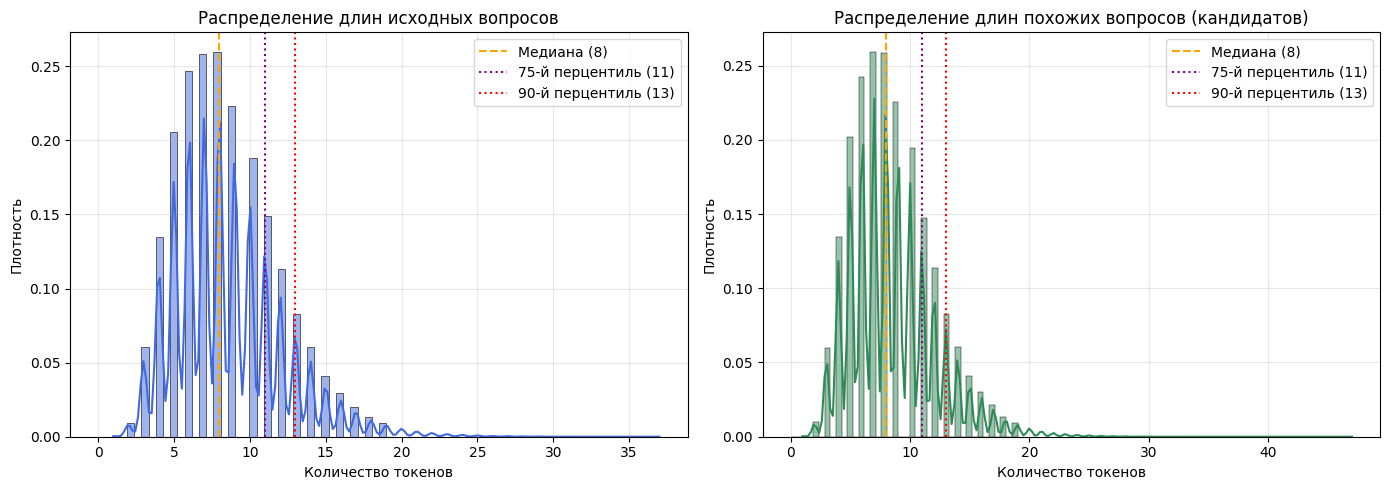

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(
    question_lens,
    bins=40,
    kde=True,
    color="royalblue",
    stat="density",
    binrange=(0, int(q_p90 * 1.5)),
)

plt.axvline(q_p50, color="orange", linestyle="--", label=f"Медиана ({q_p50:.0f})")
plt.axvline(q_p75, color="purple", linestyle=":", label=f"75-й перцентиль ({q_p75:.0f})")
plt.axvline(q_p90, color="red", linestyle=":", label=f"90-й перцентиль ({q_p90:.0f})")

plt.title("Распределение длин исходных вопросов")
plt.xlabel("Количество токенов")
plt.ylabel("Плотность")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(
    candidate_lens,
    bins=40,
    kde=True,
    color="seagreen",
    stat="density",
    binrange=(0, int(c_p90 * 1.5)),
)
plt.axvline(c_p50, color="orange", linestyle="--", label=f"Медиана ({c_p50:.0f})")
plt.axvline(c_p75, color="purple", linestyle=":", label=f"75-й перцентиль ({c_p75:.0f})")
plt.axvline(c_p90, color="red", linestyle=":", label=f"90-й перцентиль ({c_p90:.0f})")

plt.title("Распределение длин похожих вопросов (кандидатов)")
plt.xlabel("Количество токенов")
plt.ylabel("Плотность")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### min_count = 5, как предложено в задании

In [35]:
import logging
import time
from gensim.models.callbacks import CallbackAny2Vec

In [36]:
logging.getLogger("gensim").setLevel(logging.WARNING)

class EpochLogger(CallbackAny2Vec):

  def __init__(self, total_epochs):
    self.epoch = 1
    self.total_epochs = total_epochs
    self.start_time = None

  def on_epoch_begin(self, model):
    self.start_time = time.time()

  def on_epoch_end(self, model):
    elapsed = time.time() - self.start_time
    print(
        f"Эпоха {self.epoch}/{self.total_epochs} завершена за {elapsed:.1f} сек."
    )
    self.epoch += 1

In [37]:
from gensim.models import Word2Vec

embeddings_trained = Word2Vec(res_tokens, # data for model to train on
                              vector_size=200,                 # embedding vector size
                              min_count=5,             # consider words that occured at least 5 times
                              window=13,
                              sg=1,
                              epochs=5,
                              workers=2,
                              negative=10,
                              callbacks=[EpochLogger(5)]).wv

Эпоха 1/5 завершена за 391.6 сек.
Эпоха 2/5 завершена за 391.4 сек.
Эпоха 3/5 завершена за 388.9 сек.
Эпоха 4/5 завершена за 390.0 сек.
Эпоха 5/5 завершена за 386.9 сек.


In [38]:
wv_ranking = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates(q, ex, embeddings_trained, tokenizer)
    wv_ranking.append([r[0] for r in ranks].index(0) + 1)

  0%|          | 0/3760 [00:00<?, ?it/s]

In [43]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.266 | Hits@   1: 0.266
DCG@   5: 0.315 | Hits@   5: 0.361
DCG@  10: 0.330 | Hits@  10: 0.408
DCG@ 100: 0.369 | Hits@ 100: 0.598
DCG@ 500: 0.399 | Hits@ 500: 0.832
DCG@1000: 0.417 | Hits@1000: 1.000


Результат пока не догоняет предобученные эмбеддинги, хотя и стремится к этому (top10 0.408 против 0.428). У нас слишком много информации теряется (почти 79%) при установке min_count=5. Попробуем сделать что то с этим параметром.

Также уменьшим окно, чтобы:
1) ускорить обучение
2) снизить размывание семантики слишком далеким контекстом

За счет уменьшения окна и ускорения обучения, можно увеличить число эпох, чтобы дать модели лучше запомнить закономерности контекста использования слов

min_count = 2 (намеренно нарушим правило задания, чтобы улучшить модель), чтобы не выбрасывать 78.9% контекста, но при этом не зашумлять 52% слишком частовстречаемых слов

In [65]:
embeddings_trained = Word2Vec(res_tokens, # data for model to train on
                              vector_size=200,                 # embedding vector size
                              min_count=2,             # consider words that occured at least 5 times
                              window=10, # ближе к 75-процентилю, потому что раньше училось слишклм долго
                              sg=1,
                              epochs=8,
                              workers=2,
                              negative=10,
                              callbacks=[EpochLogger(8)]).wv

Эпоха 1/8 завершена за 375.3 сек.
Эпоха 2/8 завершена за 375.3 сек.
Эпоха 3/8 завершена за 375.4 сек.
Эпоха 4/8 завершена за 371.3 сек.
Эпоха 5/8 завершена за 375.1 сек.
Эпоха 6/8 завершена за 372.7 сек.
Эпоха 7/8 завершена за 371.1 сек.
Эпоха 8/8 завершена за 368.5 сек.


In [66]:
wv_ranking = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates(q, ex, embeddings_trained, tokenizer)
    wv_ranking.append([r[0] for r in ranks].index(0) + 1)

  0%|          | 0/3760 [00:00<?, ?it/s]

In [67]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.212 | Hits@   1: 0.212
DCG@   5: 0.266 | Hits@   5: 0.313
DCG@  10: 0.278 | Hits@  10: 0.350
DCG@ 100: 0.314 | Hits@ 100: 0.530
DCG@ 500: 0.346 | Hits@ 500: 0.779
DCG@1000: 0.369 | Hits@1000: 1.000


Попробуем добавить tf-idf принцип, чтобы снизить значимость стоп-слов

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer

words = [''.join(tokens) for tokens in res_tokens]
tfidf = TfidfVectorizer(tokenizer=str.split, lowercase=False)
tfidf.fit(words)

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TfidfVectorizer(lowercase=False, tokenizer=<method 'split' of 'str' objects>)

In [74]:
tfidf.get_feature_names_out()[:5]

array(["''''c\\programisnotrecognizedasaninternalorexternalcommandoperableprogramorbatchfilesparkshellwhydoesspark-shellfailwith``''''c\\programisnotrecognizedasaninternalorexternalcommand''onwindows",
       "''''c\\programisnotrecognizedasaninternalorexternalcommandoperableprogramorbatchfilesparkshellwhydoesspark-shellfailwith``wasunexpectedatthistime''",
       "''isnotavalididentifierdelphixe5howdoiidentifywhatcodeisgenerating````isnotavalidfloatingpointvalue''errordialoguebox",
       "''java.exe''isnotrecognizedasaninternalorexternalcommandhowtofixjava.lang.unsupportedclassversionerrorunsupportedmajor.minorversion",
       "''java.exe''isnotrecognizedasaninternalorexternalcommandjava.lang.unsupportedclassversionerror"],
      dtype=object)

In [81]:
idf_weights = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

Получились какие-то вообще неосмысленные токены. Все таки вернемся к рекомендованному min_count=5 в будущем

In [78]:
def question_to_vec_idf(question, embeddings, tokenizer, idf_weights, default_idf=None, dim=200):
    """
        question: строка
        embeddings: наше векторное представление
        dim: размер любого вектора в нашем представлении

        return: векторное представление для вопроса
    """
    if default_idf is None:
        default_idf = max(idf_weights.values())

    tokens = tokenizer(question)
    res = np.zeros(dim)
    cnt = 0
    for token in tokens:
        if token in embeddings:
            v = embeddings[token]
            norm = np.linalg.norm(v)
            if norm > 0:
                w = idf_weights.get(token, default_idf)
                res += (v / norm) * w
                cnt += w
    return res / cnt if cnt != 0 else res

In [85]:
def rank_candidates_idf(question, candidates, embeddings, tokenizer, idf_weights, dim=200):
    """
        question: строка
        candidates: массив строк(кандидатов) [a, b, c]
        result: пары (начальная позиция, кандидат) [(2, c), (0, a), (1, b)]
    """
    question_embed = question_to_vec_idf(question, embeddings, tokenizer, idf_weights, dim).reshape(1, -1)

    candidates_embed = np.array([question_to_vec_idf(cand, embeddings, tokenizer, idf_weights, dim) for cand in candidates])

    cosine_scores = cosine_similarity(question_embed, candidates_embed)[0]
    idxs = np.argsort(cosine_scores)[::-1]

    result = [(idx.item(), candidates[idx]) for idx in idxs]
    return result

In [86]:
wv_ranking = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates_idf(q, ex, embeddings_trained, tokenizer, idf_weights)
    wv_ranking.append([r[0] for r in ranks].index(0) + 1)

  0%|          | 0/3760 [00:00<?, ?it/s]

In [87]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.212 | Hits@   1: 0.212
DCG@   5: 0.266 | Hits@   5: 0.313
DCG@  10: 0.278 | Hits@  10: 0.350
DCG@ 100: 0.314 | Hits@ 100: 0.530
DCG@ 500: 0.346 | Hits@ 500: 0.779
DCG@1000: 0.369 | Hits@1000: 1.000


Получился результат хуже. Значит окно маловато или слишком много шума в данных (за счет уменьшения min_count). Как было сказано ранее, вернем его на 5. Попробуем вернуть окно ближе к 90-перцентилю и добавить стемминг в обработку токенов

In [88]:
from nltk.stem import SnowballStemmer

ss = SnowballStemmer(language='english')

In [91]:
def stem_tokenizer(text):
  tokens = tokenizer(text)
  return [ss.stem(w) for w in tokens]

In [92]:
res_tokens_stem, question_lens_stem, candidate_lens_stem = cat_train_data(train_data, stem_tokenizer)

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [93]:
embeddings_trained = Word2Vec(res_tokens,
                              vector_size=200,
                              min_count=5,
                              window=12,
                              sg=1,
                              epochs=8,
                              workers=2,
                              negative=5,
                              callbacks=[EpochLogger(8)]).wv

Эпоха 1/8 завершена за 205.8 сек.
Эпоха 2/8 завершена за 206.3 сек.
Эпоха 3/8 завершена за 205.8 сек.
Эпоха 4/8 завершена за 203.6 сек.
Эпоха 5/8 завершена за 204.8 сек.
Эпоха 6/8 завершена за 205.5 сек.
Эпоха 7/8 завершена за 204.4 сек.
Эпоха 8/8 завершена за 202.6 сек.


In [94]:
wv_ranking = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates(q, ex, embeddings_trained, stem_tokenizer)
    wv_ranking.append([r[0] for r in ranks].index(0) + 1)

  0%|          | 0/3760 [00:00<?, ?it/s]

In [95]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.275 | Hits@   1: 0.275
DCG@   5: 0.336 | Hits@   5: 0.391
DCG@  10: 0.355 | Hits@  10: 0.448
DCG@ 100: 0.393 | Hits@ 100: 0.639
DCG@ 500: 0.424 | Hits@ 500: 0.879
DCG@1000: 0.436 | Hits@1000: 1.000


Вот мы и получили результат лучше, чем с эмбеддингами, обученными на StackOverflow
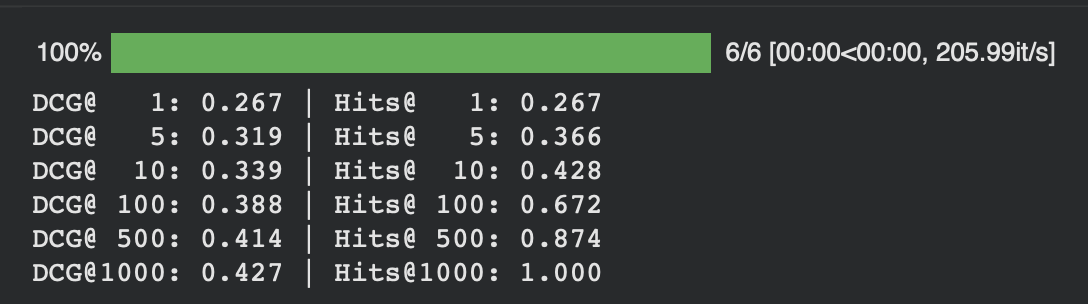

### Замечание:
Решить эту задачу с помощью обучения полноценной нейронной сети будет вам предложено, как часть задания в одной из домашних работ по теме "Диалоговые системы".

Напишите свой вывод о полученных результатах.
* Какой принцип токенизации даёт качество лучше и почему?
* Помогает ли нормализация слов?
* Какие эмбеддинги лучше справляются с задачей и почему?
* Почему получилось плохое качество решения задачи?
* Предложите свой подход к решению задачи.

## Вывод:


***Ваш вывод:***
В целом, весь процесс того, как я рассуждал и почему применял те или иные параметры модели Word2Vec я расписывал прямо перед тем, как писать код. Здесь сделаю краткие выводы и подведу итоги

- Лучшего качества получилось добиться, применяя обучение Word2Vec на парах похожих вопросов. Это работает, тк за счет контекстного окна модель учится понимать, какие слова могут использоваться вместе. Окно, почти равное 90 перцентилю помогло сделать так, чтобы даже начальные слова одного предложения "пары" видели слова контекста из другого предложения "пары".
- Нормализация слов однозначно нужна, потому что английсикй язык могуч и богат, а значит есть много слов, имеющих одинаковое значение при разных окончаниях/приставках/... Здесь я использовал стемминг, тк он помогает сжать редкие формы слов без значительного расхода по времени, что нужно было бы для лемматизации
- Эмбеддинги, обученные чреез skip-gram (аргумент sg=1) дают лучший результат в задаче ранкинга (в отличие от cbow он не усредняет вектор контекста в одно общее представление, а генерирует отдельные обучающие пары для каждого слова контекста), но взамен требуют больших вычислительных ресурсов на обучении. Если использовать negative sampling, обучение получается быстрее, за счет того, что градиенты текут не по всем веткорам, а только по выбранным k (у меня 5 в последней вариации)
- Плохое качество получилось, потому что:
  1) Требуется больше времени на обучение (больше эпох)
  2) Требуется больше датасет
  3) Если посмотреть, какие бредовые получились токены, если ставить min_count=2, можно сделать вывод в целом о качестве текстов (много логов, какой-то неполезной информации, которая встречается всего 1 раз). если мы берем min_count=5, то выбрасываем почти 79% информации о корпусе текстов
  4) Word2Vec не берет глобальную информацию о выборке, поэтому можно было использовать GloVe в качестве решения этой проблемы
  5) Все таки отдельно эмбеддинги без какой-то дополнительной информации не могут в полной мере описать, насколько сильно похожи тексты. Они не дают понимания порядка слов, отрицания и в целом синтаксиса
- Мой подход: использовать стемминг/лемматизацию и GloVe/FastText, как варианты улучшения полученного результата